# STEP 8 — Profit-oriented baseline: ProfLogit vs our approach

Closes the objection "if you're profit-oriented, why didn't you compare against a profit-trained model?".
Two approaches (5 sets, stratified 5-fold, seed=42, same CLV/profit parameters, same encode+scale):
**(A) Ours** = raw LightGBM (Step 2 best_params) + profit-maximizing threshold t*;
**(B) ProfLogit** = a model that directly **maximizes EMPC** over the logistic coefficients
(real-coded genetic search, warm-start = MLE logistic). All fit/threshold is fold-internal only.
ProfLogit scientific citation: Stripling et al. (2018). The heavy logic lives in `src/proflogit_baseline.py`.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml not found")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from scipy.stats import wilcoxon

from src import config as cfg
from src import plotstyle as ps
from src import proflogit_baseline as pb
from src import strings as S

ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))


yaz(S.MSG8["atif"])

ProfLogit method: Stripling, vanden Broucke, Antonio, Baesens, Snoeck (2018), 'Profit maximizing logistic model for customer churn prediction using genetic algorithms' (EMPC objective + genetic coefficient search).


## 1. Each set: run both approaches with 5-fold

In [2]:
import time

veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
yaz(S.MSG["bolum"].format(ad="PROFLOGIT vs OURS"))
tum = {}
for k in cfg.DATASETS:
    t = time.time()
    met, n, N = pb.calistir_set(k, veriler[k], cfg.SEED)
    tum[k] = (met, n, N)
    if N > n:
        yaz(S.MSG8["ornek"].format(set=k, n=n, N=N, seed=cfg.SEED))
    for adi in ("ours", "proflogit"):
        m = met[adi]
        yaz(S.MSG8["set"].format(set=k, yaklasim=S.YAKLASIM_AD[adi], empc=np.mean(m["EMPC"]),
            kar=np.mean(m["kar"]), roi=np.mean(m["roi"]), pr=np.mean(m["PR-AUC"]),
            sure=(time.time() - t) / 2))

===== PROFLOGIT vs OURS =====


telco / Ours (raw LightGBM + profit threshold): EMPC=0.0504 profit=110205 ROI=1.34 PR-AUC=0.664 (3s)
telco / ProfLogit (EMPC-maximizing): EMPC=0.0492 profit=107522 ROI=1.33 PR-AUC=0.655 (3s)


cell2cell: stratified sample n=15000 for ProfLogit (full data 51047), seed=42.
cell2cell / Ours (raw LightGBM + profit threshold): EMPC=0.0350 profit=148255 ROI=0.70 PR-AUC=0.454 (12s)
cell2cell / ProfLogit (EMPC-maximizing): EMPC=0.0350 profit=148085 ROI=0.70 PR-AUC=0.378 (12s)


ecommerce / Ours (raw LightGBM + profit threshold): EMPC=0.0161 profit=53895 ROI=1.44 PR-AUC=0.908 (9s)
ecommerce / ProfLogit (EMPC-maximizing): EMPC=0.0062 profit=20576 ROI=0.21 PR-AUC=0.678 (9s)


iranian / Ours (raw LightGBM + profit threshold): EMPC=0.0010 profit=314 ROI=0.11 PR-AUC=0.958 (10s)
iranian / ProfLogit (EMPC-maximizing): EMPC=-0.0101 profit=-3008 ROI=-0.69 PR-AUC=0.750 (10s)


bank / Ours (raw LightGBM + profit threshold): EMPC=0.0324 profit=198082 ROI=0.93 PR-AUC=0.706 (6s)
bank / ProfLogit (EMPC-maximizing): EMPC=0.0350 profit=214021 ROI=1.01 PR-AUC=0.437 (6s)


## 2. Table + pooled significance

In [3]:
df = pb.tablo(tum)
yaz(S.MSG["bolum"].format(ad="COMPARISON TABLE (fold mean ± std)"))
yaz(df.to_string(index=False))
# pooled (set×fold) Wilcoxon
oe = np.concatenate([tum[k][0]["ours"]["EMPC"] for k in cfg.DATASETS])
pe_pl = np.concatenate([tum[k][0]["proflogit"]["EMPC"] for k in cfg.DATASETS])
ok = np.concatenate([tum[k][0]["ours"]["kar"] for k in cfg.DATASETS])
pk_pl = np.concatenate([tum[k][0]["proflogit"]["kar"] for k in cfg.DATASETS])
pe = wilcoxon(oe, pe_pl).pvalue
pk = wilcoxon(ok, pk_pl).pvalue
yaz(S.MSG8["wilcoxon"].format(n=len(oe), pe=pe, pk=pk))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "profit_baseline_comparison.csv"))

===== COMPARISON TABLE (fold mean ± std) =====
  Dataset                               Approach             EMPC         Profit    ROI          PR-AUC  Recall  Precision    F1  p (EMPC, Wilcoxon)  p (profit, Wilcoxon)
    telco Ours (raw LightGBM + profit threshold)  0.0504 ± 0.0021  110205 ± 3839  1.343 0.6635 ± 0.0223   0.985      0.348 0.514              0.1250                0.1250
    telco            ProfLogit (EMPC-maximizing)  0.0492 ± 0.0027  107522 ± 5178  1.332 0.6554 ± 0.0271   0.981      0.353 0.519              0.1250                0.1250
cell2cell Ours (raw LightGBM + profit threshold)  0.0350 ± 0.0010  148255 ± 5605  0.701 0.4542 ± 0.0101   1.000      0.289 0.448              0.6250                0.5000
cell2cell            ProfLogit (EMPC-maximizing)  0.0350 ± 0.0010  148085 ± 5741  0.700 0.3783 ± 0.0128   1.000      0.288 0.448              0.6250                0.5000
ecommerce Ours (raw LightGBM + profit threshold)  0.0161 ± 0.0054  53895 ± 18355  1.443 0.9084 ± 0

## 3. Figures

Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_baseline/proflogit_vs_ours_empc.png
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_baseline/proflogit_vs_ours_profit.png


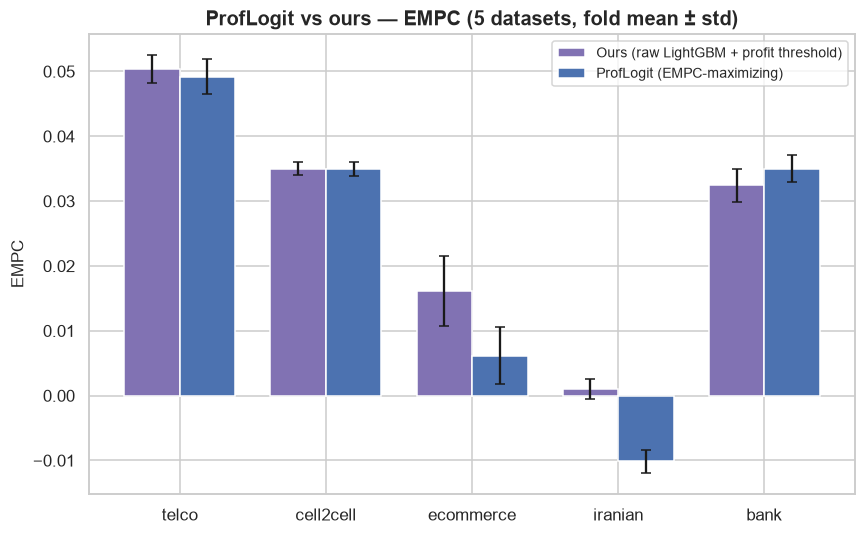

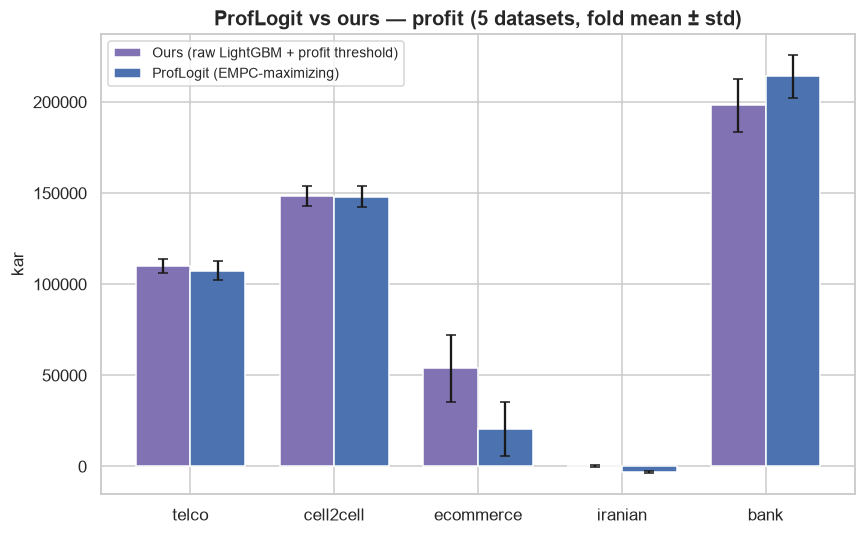

In [4]:
for y in pb.figurler(tum):
    yaz(S.MSG["kayit"].format(yol=y))

## 4. Summary — is the profit-threshold enough? (decision left to the user)

In [5]:
yaz(S.MSG["bolum"].format(ad="SUMMARY"))
for k in cfg.DATASETS:
    m = tum[k][0]
    de = np.mean(m["ours"]["EMPC"]) - np.mean(m["proflogit"]["EMPC"])
    dk = np.mean(m["ours"]["kar"]) - np.mean(m["proflogit"]["kar"])
    kazanan = "ours" if de >= 0 else "ProfLogit"
    yaz(f"  {k:11s} EMPC diff(ours−PL)={de:+.4f} profit diff={dk:+.0f} -> {kazanan} ahead")
yaz(f"\nPooled: EMPC p={pe:.4f}, profit p={pk:.4f} "
    f"({'significant' if pe < 0.05 else 'noise'} / {'significant' if pk < 0.05 else 'noise'})")
yaz(S.MSG8["bitti"])

_log = cfg.LOGS / "adim8_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== SUMMARY =====
  telco       EMPC diff(ours−PL)=+0.0012 profit diff=+2683 -> ours ahead
  cell2cell   EMPC diff(ours−PL)=+0.0000 profit diff=+169 -> ours ahead
  ecommerce   EMPC diff(ours−PL)=+0.0099 profit diff=+33319 -> ours ahead
  iranian     EMPC diff(ours−PL)=+0.0111 profit diff=+3322 -> ours ahead
  bank        EMPC diff(ours−PL)=-0.0026 profit diff=-15939 -> ProfLogit ahead

Pooled: EMPC p=0.0152, profit p=0.1194 (significant / noise)
STEP 8 complete. Profit-driven baseline compared; interpretation left to the user.
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/logs/adim8_ozet.log
